## Задача 2. Линейная регрессия, метод градиентного спуска

### Васаулюа Брюнотт Тази М81

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.impute import KNNImputer
import seaborn as sns
from tabulate import tabulate
from sklearn.model_selection import train_test_split
import abc
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import RFECV
from sklearn.linear_model import Ridge
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import (check_scalar, check_X_y, check_array, check_random_state, check_is_fitted)
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.utils.estimator_checks import check_estimator
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from math import ceil
from numbers import Integral, Real

Самостоятельно реализовать функцию **gradient_descent(X, y)**, которая по заданной обучающей выборке обучает модель линейной регрессии, оптимизируя функционал **методом градиентного спуска (Batch Gradient Descent, GD)** и возвращая вектор весов **w**. В качестве функционала можно выбрать, например, функцию ошибок **MSE** + $L_2$-регуляризатор. Использовать матрично-векторные операции для вычисления градиента.

Реализация функции gradient_descent(X, y):

Шаг 1: Определение функционала
Мы будем использовать функцию ошибок MSE (Mean Squared Error) + $L_2$-регуляризатор. Функция ошибок MSE определяется как:

MSE = (1/n) * ∑$(y_t - y_p)^2$

где $y_t$ - истинные значения, $y_p$ - предсказанные значения, n - количество образцов в обучающей выборке.

$L_2$-регуляризатор определяется как:

$L_2$ = λ * $||w||^2$

где λ - коэффициент регуляризации, w - вектор весов.

Общий функционал имеет вид:

J(w) = MSE + $L_2$

Шаг 2: Вычисление градиента
Градиент функционала J(w) по отношению к вектору весов w определяется как:

∇J(w) = ∂J(w)/∂w

Используя матрично-векторные операции, мы можем вычислить градиент следующим образом:

∇J(w) = (2/n) * $X^T$ * (X * w - y) + 2 * λ * w

где X - матрица признаков, $X^T$ - транспонированная матрица признаков.

Шаг 3: Реализация метода градиентного спуска
Метод градиентного спуска включает в себя итеративное обновление вектора весов w в направлении, противоположном градиенту функционала J(w).

w ← w - α * ∇J(w)

где α - шаг обучения.

In [4]:
"""
Параметры:
    X (numpy.array): матрица признаков
    y (numpy.array): вектор целевых переменных
    alpha (float): шаг обучения (по умолчанию 0.01)
    lambda_ (float): коэффициент регуляризации (по умолчанию 0.1)
    num_iterations (int): количество итераций (по умолчанию 1000)

    Возвращает:
    w (numpy.array): вектор весов
"""

def gradient_descent(X, y, alpha=0.01, lambda_=0.1, num_iterations=1000):
    n, d = X.shape
    w = np.zeros(d)  # Initialize weights
    bias = 0  # Initialize bias

    for _ in range(num_iterations):
        # Compute predictions
        y_pred = X.dot(w) + bias
        
        # Compute the error
        error = y_pred - y
        
        # Compute the gradient for weights and bias
        gradient_w = (2 / n) * X.T.dot(error) + 2 * lambda_ * w
        gradient_b = (2 / n) * np.sum(error)
        
        # Update the weights and bias
        w -= alpha * gradient_w
        bias -= alpha * gradient_b

    return w, bias

# Генерируем обучающую выборку
np.random.seed(42)
X = np.random.rand(100, 5)
y = 3 * X[:, 0] + 2 * X[:, 1] + np.random.randn(100)


# Обучаем модель методом градиентного спуска
w = gradient_descent(X, y)
# plt.plot(x, y)
# plt.show()
# Выводим вектор весов
print("Вектор весов:", w)

Вектор весов: (array([ 1.21228647,  0.69486377,  0.16405661,  0.08136866, -0.20964684]), np.float64(1.5360303151874506))


Найти данные, на которых интересно будет решать задачу регрессии. Зависимость целевого признака от нецелевых должна быть не слишком сложной, чтобы обученная линейная модель смогла показать приемлимый результат. В крайнем случае взять данные для предсказания стоимости машин [тут](https://github.com/rustam-azimov/ml-course-itmo/tree/main/data/car_price) (целевой признак для предсказания --- **price**).

Считать данные, выполнить первичный анализ данных, при необходимости произвести чистку данных (**Data Cleaning**).

При необходимости выполнить полезные преобразования данных (например, трансформировать категариальные признаки в количественные), убрать ненужные признаки, создать новые (**Feature Engineering**).

--> Буду работать с данными из задачи 1 : [Real Estate Saint Petersburg 2014 - 2019 (Недвижимость Санкт-Петербурга 2014 - 2019)](https://www.kaggle.com/datasets/litvinenko630/real-estate-saint-petersburg-2014-2019) из Kaggle.
Они уже чистие и готовые к использованию. Данные содержат информацию о продаже недвижимости в  Санкт-Петербурге с 2014 по 2019 год. Целевой признак для предсказания --- **last_price**

In [5]:
# Данные до и после чистки и преобразования
print("\nДанные до(0) и после(1) чистки и преобразования:\nОбратите внимание NaN означает что столбец не существует!!")
all_data = pd.read_csv(r"spb\spb_real_estate_data.csv", sep='\t', encoding='utf-8')
cleaned_data = pd.read_csv(r"spb\cleaned_data.csv", encoding='utf-8')
data1 = all_data.isnull().sum()
data2 = cleaned_data.isnull().sum()

df_concat = pd.concat([data1, data2], axis=1)

print(df_concat)


Данные до(0) и после(1) чистки и преобразования:
Обратите внимание NaN означает что столбец не существует!!
                            0    1
total_images              0.0  NaN
last_price                0.0  0.0
total_area                0.0  0.0
first_day_exposition      0.0  NaN
rooms                     0.0  0.0
ceiling_height         9195.0  0.0
floors_total             86.0  0.0
living_area            1903.0  0.0
floor                     0.0  0.0
is_apartment          20924.0  0.0
studio                    0.0  0.0
open_plan                 0.0  0.0
kitchen_area           2278.0  0.0
balcony               11519.0  0.0
locality_name            49.0  0.0
airports_nearest       5542.0  0.0
cityCenters_nearest    5519.0  0.0
parks_around3000       5518.0  0.0
parks_nearest         15620.0  0.0
ponds_around3000       5518.0  0.0
ponds_nearest         14589.0  0.0
days_exposition        3181.0  NaN
price_per_area            NaN  0.0


Выполнить разведочный анализ (**EDA**), использовать визуализацию, сделать выводы, которые могут быть полезны при дальнейшем решении задачи регрессии.

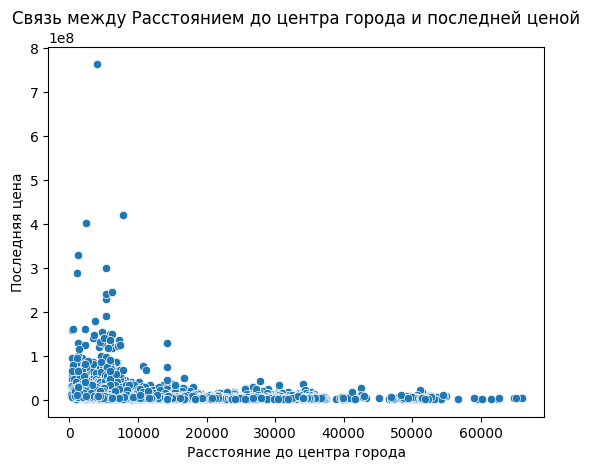

In [6]:
sns.scatterplot(x='cityCenters_nearest', y='last_price', data=cleaned_data)
plt.title('Связь между Расстоянием до центра города и последней ценой')
plt.xlabel('Расстояние до центра города')
plt.ylabel('Последняя цена')
plt.show()


Text(0.5, 1.0, 'Распределение цен ')

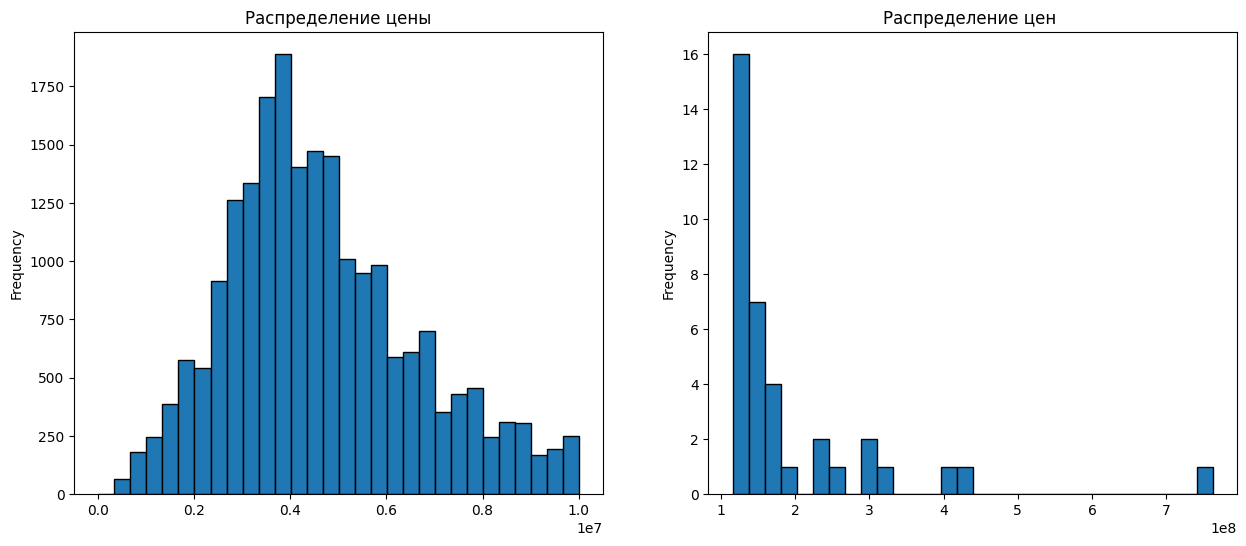

In [7]:
_, ax = plt.subplots(1, 2, figsize=(15, 6))
cleaned_data[cleaned_data['last_price'] <= 5+1e7]['last_price'].plot.hist(ax=ax[0], edgecolor='black', bins=30)
ax[0].set_title('Распределение цены')

cleaned_data[cleaned_data['last_price'] >= 1+1e8]['last_price'].plot.hist(ax=ax[1],  edgecolor='black', bins=30)
ax[1].set_title('Распределение цен ')

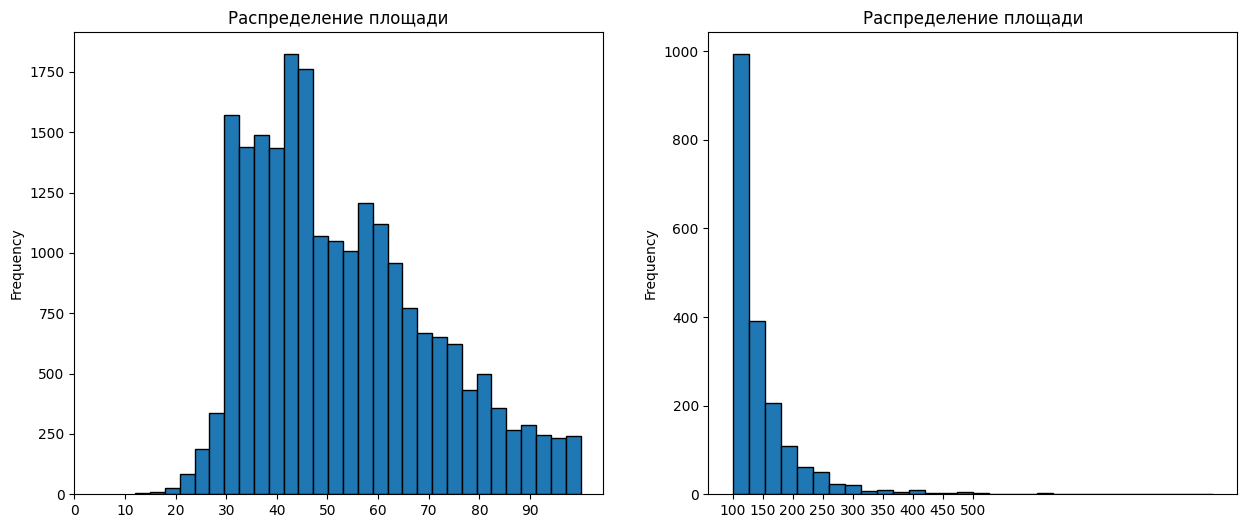

In [8]:
_, ax = plt.subplots(1, 2, figsize=(15, 6))
cleaned_data[cleaned_data['total_area'] <= 100]['total_area'].plot.hist(ax=ax[0], edgecolor='black', bins=30)
ax[0].set_title('Распределение площади')
x1 = list(range(0, 100, 10))
ax[0].set_xticks(x1)
cleaned_data[cleaned_data['total_area'] >= 100]['total_area'].plot.hist(ax=ax[1], edgecolor='black', bins=30)
ax[1].set_title('Распределение площади')
x1 = list(range(100, 550, 50))
ax[1].set_xticks(x1)

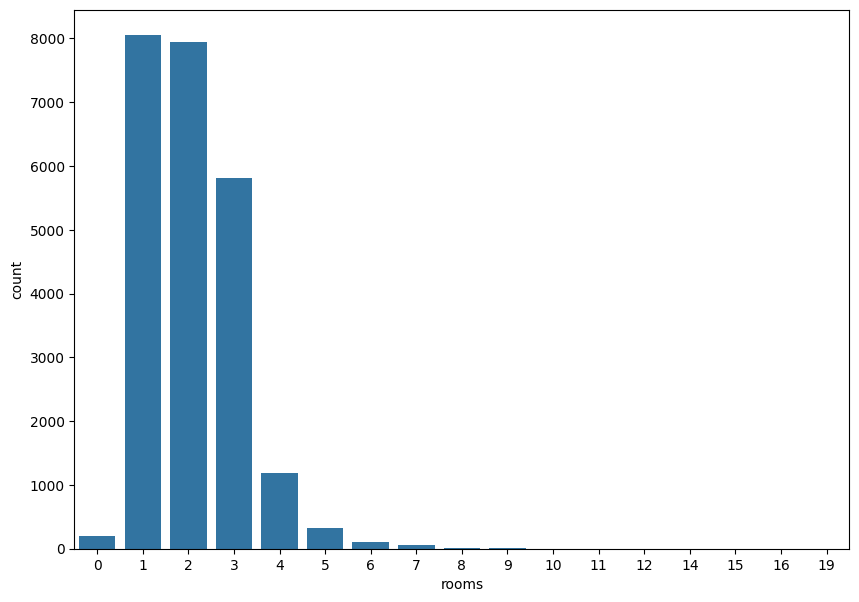

In [9]:
plt.figure(figsize=(10, 7))
sns.countplot(x=cleaned_data["rooms"])
plt.show()

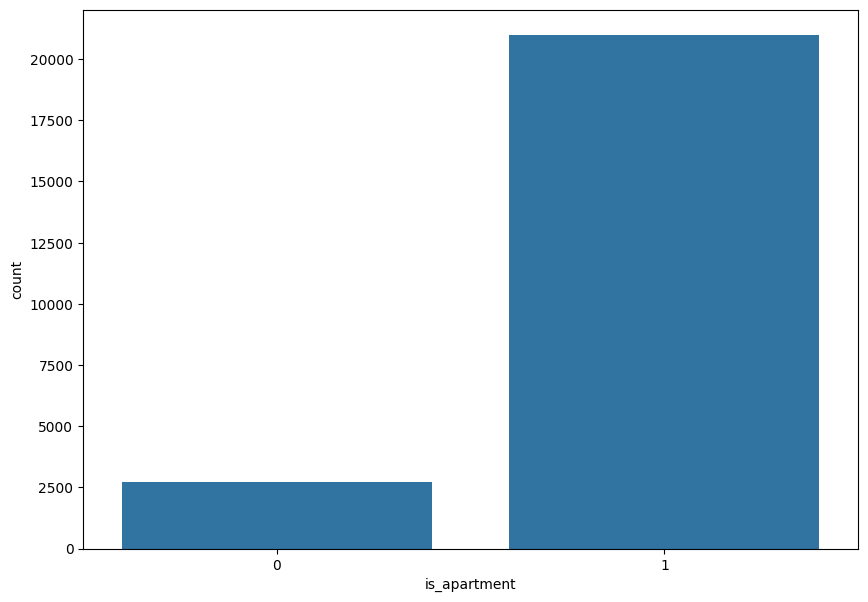

In [10]:
plt.figure(figsize=(10, 7))
sns.countplot(x=cleaned_data["is_apartment"])
plt.show()

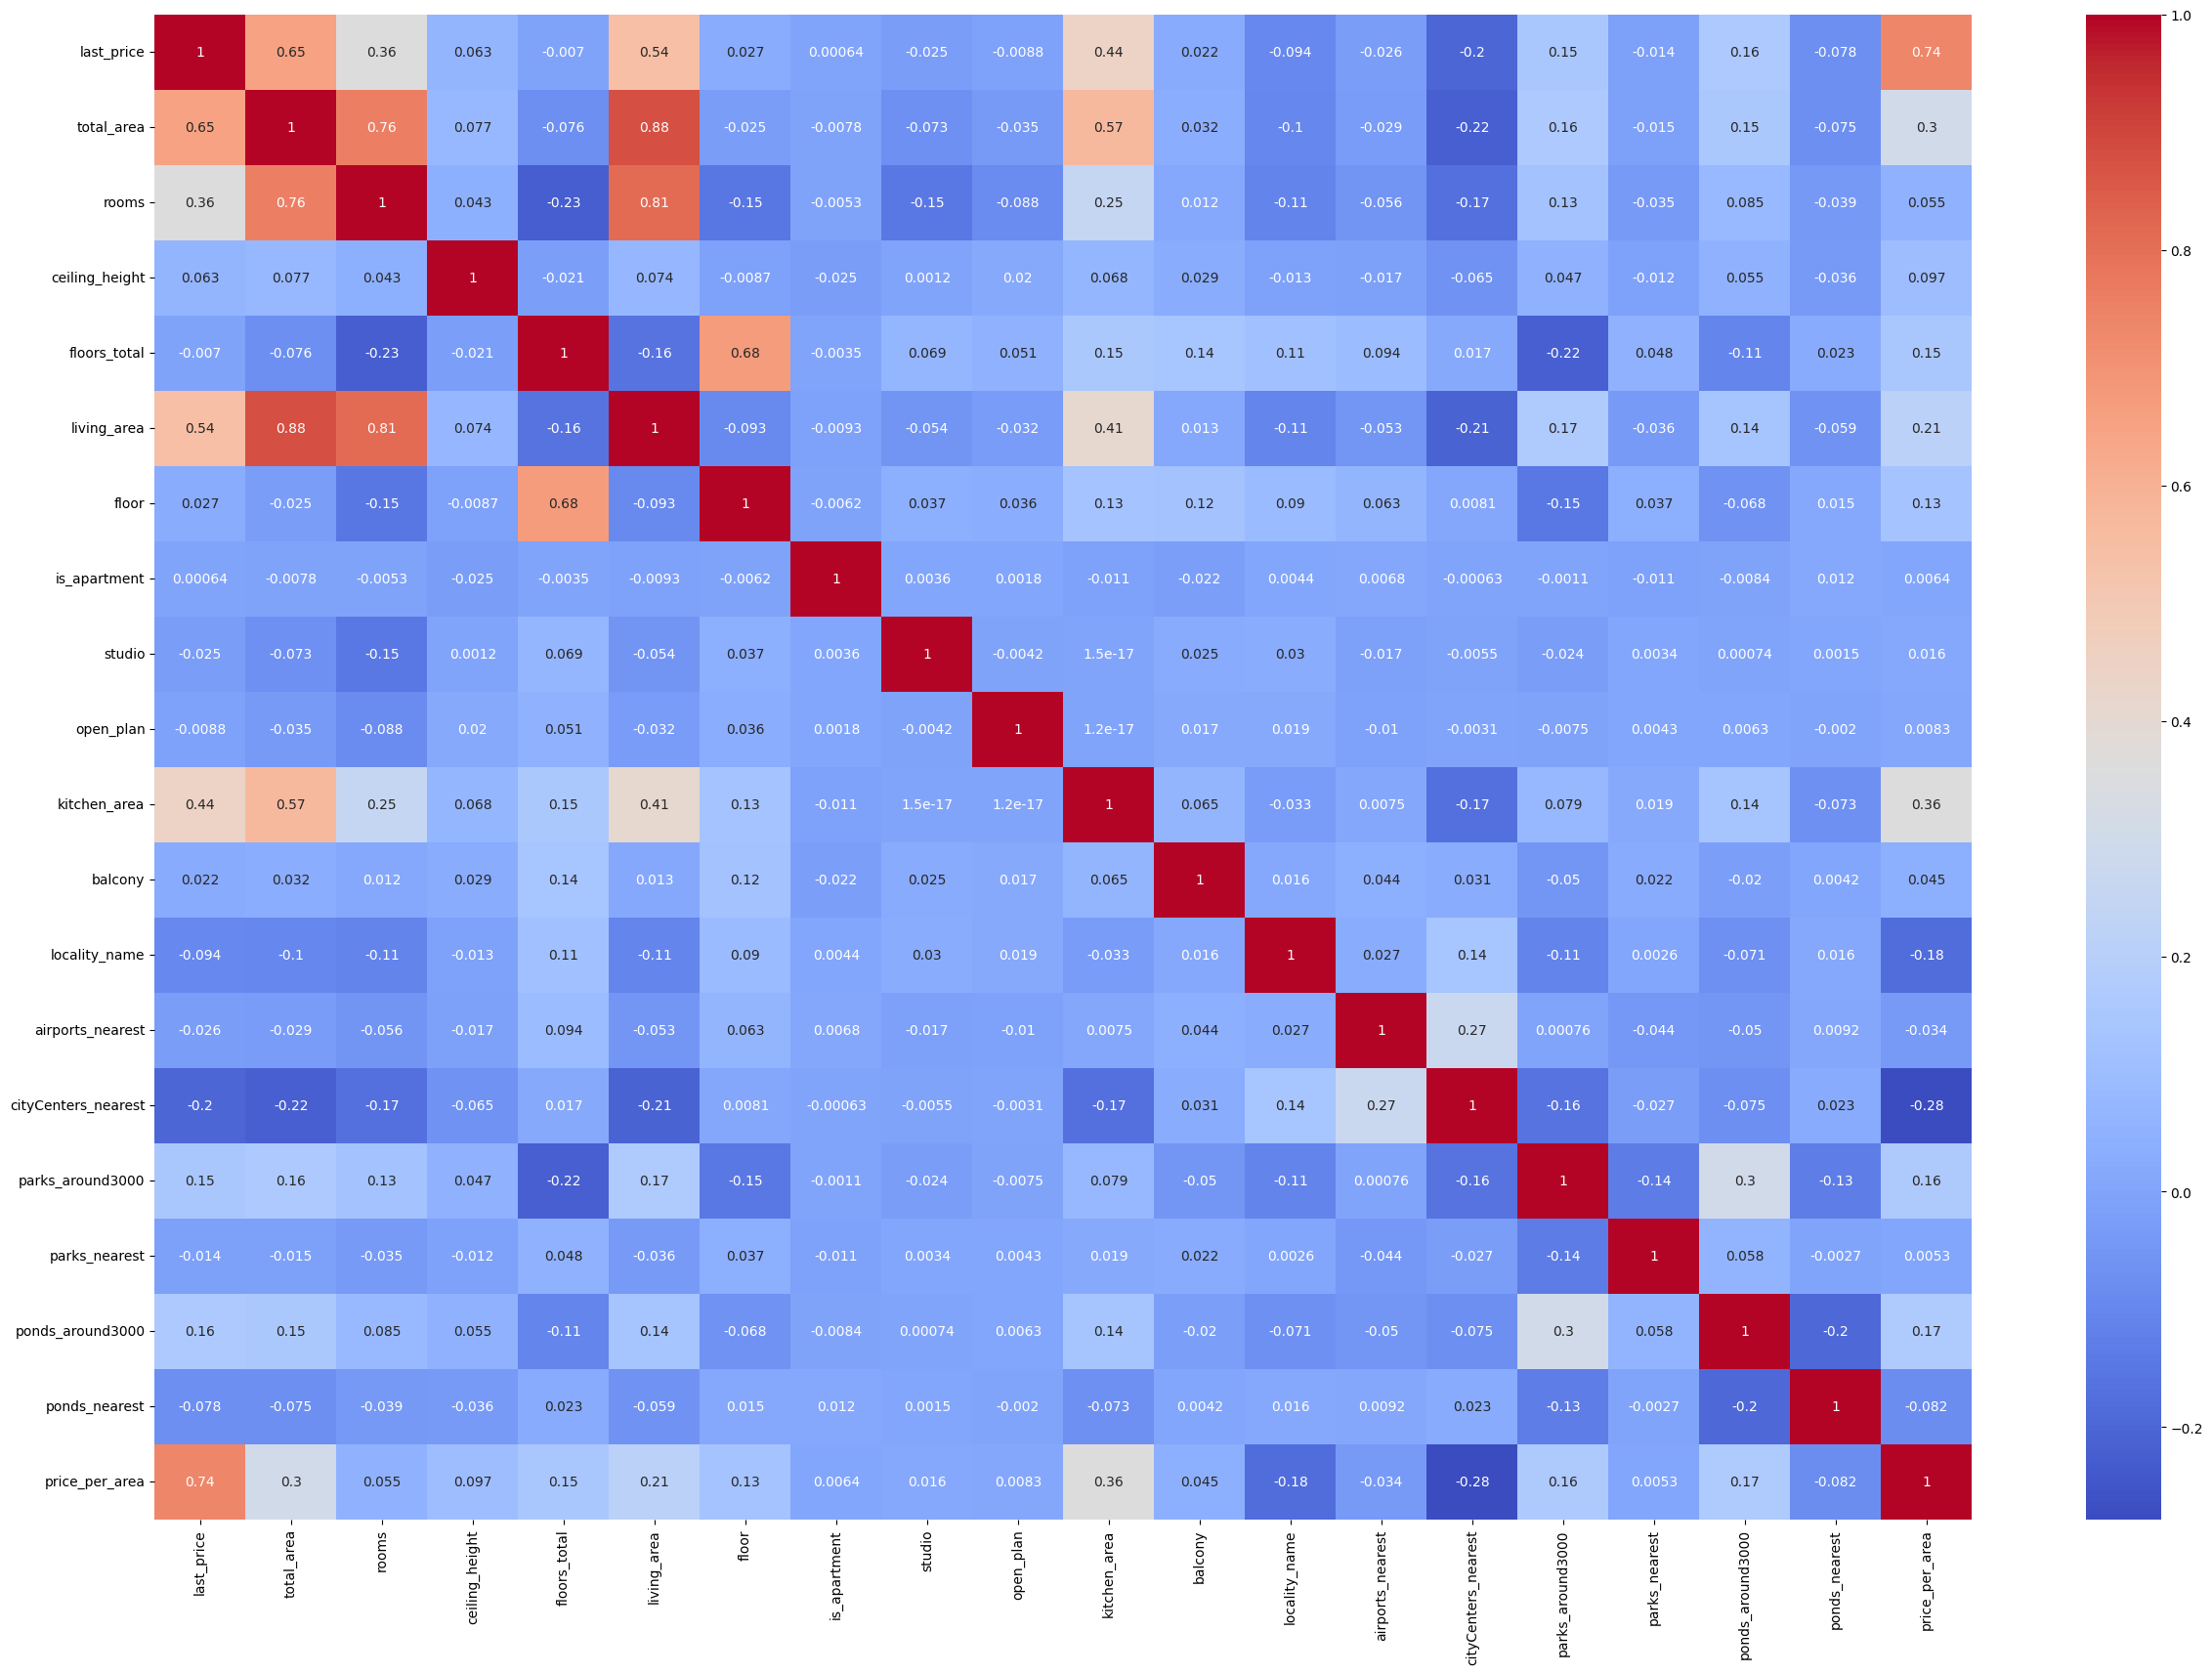

In [11]:
corr_matrix = cleaned_data.corr()
plt.figure(figsize=(30, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show() 

## Вывод
* Общая площадь большинства объектов варьируется от 40 до 60 квадратных метров.
* Чем ближе объект к центру города, тем дороже он стоит.
* большинство объектов явл. квартирой
* Кол-во комнат большинства объектов 1
* Наиболее интересно научиться предсказывать цену по остальным признакам. По таблице коррелации можно увидеть, что на цену  наиболее сильно влияют:Citycenters_narest: Расстояние до центра города в метрах,kitchen_area: Площадь кухни в квадратных метрах, living_area: Жилая площадь в квадратных метрах, rooms: Количество комнат,total_area: Общая площадь объекта в квадратных метрах. При увеличении например total_area: Общая площадь объекта в квадратных метрах, цена возрастает, а при увеличении Расстояния до центра города, цена падает, исходя из знака коэффициента.

### Обобщенная реализация градиентного спуска 
- метод стохастического градиентного спуска (Stochastic Gradient Descent, SGD)
- метод мини-пакетного градиентного спуска (Mini Batch Gradient Descent)
- метод градиентного спуска (Batch Gradient Descent, GD)

In [25]:
from sklearn.utils import gen_batches
from sklearn.utils import shuffle


def batch_gradient_descent(model, X, y, learning_rate, l2_coef, grad_clip_thr, update_learning_rate, epochs, batch_size, eps):

    np.random.seed(42)
    def clip_grad(grad):
        if grad_clip_thr:
            np.clip(grad, -grad_clip_thr, grad_clip_thr, out=grad)

    n_features = len(model.coef_)
    n_samples = len(X)
    losses = []

    for _ in range(epochs):
        for batch_slice in shuffle(list(gen_batches(len(X), batch_size))):
            preds = model.predict(X[batch_slice])
            error = preds - y[batch_slice]
            
            grad = np.zeros((n_features, 1))
            for i in range(n_features):
                L2 = 2 * model.coef_[i] / n_features
                grad[i] += (2 / n_samples * error.T @ X[batch_slice, i]).item() + l2_coef * L2
            clip_grad(grad)

            model.coef_ -= learning_rate * grad
            if update_learning_rate:
                learning_rate = update_learning_rate(learning_rate)

            diff_norm = np.linalg.norm(grad, ord=2)

In [26]:
# Линейная регрессия
class Model:

    def __init__(self, method="gd", learning_rate=1e-3, l2_coef=0, max_iters=100, update_learning_rate=None, epochs=100, batch_size=10, grad_clip_thr=None, eps=None):
        self.method = method
        self.learning_rate = learning_rate
        self.l2_coef = l2_coef
        self.max_iters = max_iters
        self.update_learning_rate = update_learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.grad_clip_thr = grad_clip_thr
        self.eps = eps
        
    def predict(self, X):
        return np.array(X @ self.coef_)
    
    def fit(self, X, y):
        # Здесь меняются параметры batch_gradient_descent в зависимости от метода.
        # Если это обычный gd, то батч равен всему датасету, а если это стохастический gd, то батч равен одному.
        
        np.random.seed(42)
        n_features = X.shape[1]
        self.coef_ = np.random.normal(0, n_features * 2, (n_features, 1))        
        match self.method:
            case "gd":
                batch_gradient_descent(self, X, y, learning_rate=self.learning_rate, l2_coef=self.l2_coef, grad_clip_thr=self.grad_clip_thr, update_learning_rate=self.update_learning_rate, epochs=self.max_iters, batch_size=len(X), eps=self.eps)
            case "bgd":
                batch_gradient_descent(self, X, y, learning_rate=self.learning_rate, l2_coef=self.l2_coef, grad_clip_thr=self.grad_clip_thr, update_learning_rate=self.update_learning_rate, epochs=self.epochs, batch_size=self.batch_size, eps=self.eps)
            case "sgd":
                batch_gradient_descent(self, X, y, learning_rate=self.learning_rate, l2_coef=self.l2_coef, grad_clip_thr=self.grad_clip_thr, update_learning_rate=self.update_learning_rate, epochs=self.epochs, batch_size=1, eps=self.eps)
            case _:
                raise Exception(f"No such method as {method} for .fit() in Model")

    def get_params(self, deep=True):
        return {"grad_clip_thr": self.grad_clip_thr, "method": self.method, "learning_rate": self.learning_rate, 
                "l2_coef": self.l2_coef, "max_iters": self.max_iters, "update_learning_rate": self.update_learning_rate,
                "epochs": self.epochs, "batch_size": self.batch_size, "eps": self.eps}  
    
    def set_params(self, **parameters):
        for key, value in parameters.items():
            self.__dict__[key] = value
        return self

    def score(self, X, y):
        # R^2
        preds = self.predict(X)
        return 1 - np.square(y - preds).sum() / np.square(y - np.mean(y)).sum()

Случайным образом разбить данные на **обучающую** и **тестовую** выборки, используя методы существующих библиотек.

In [19]:
X = cleaned_data.drop('last_price', axis=1)
y = cleaned_data['last_price'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

* (+2 балла) Перед обучением моделей подобрать наилучшее количество (и само подмножество) признаков, например используя **Recursive Feature Elimination (RFE)** из **sklearn**.

Ниже код выполняет выбор признаков с использованием рекурсивного исключения признаков с перекрестной проверкой (RFECV - Recursive Feature Elimination with Cross-Validation), чтобы определить наиболее важные признаки для прогнозирования целевой переменной. Он сопоставляет модель регрессии Ridge с обучающими данными, оценивает, какие функции в наибольшей степени влияют на производительность модели, а затем соответствующим образом обновляет наборы функций, сохраняя только выбранные функции для дальнейшего анализа или моделирования. Результаты выводятся на печать, чтобы показать, какие функции были сохранены, а какие удалены.

In [20]:
rfecv = RFECV(Ridge(), cv=5)
rfecv.fit(X_train, y_train)
selected_fields = X.columns[rfecv.support_]
print("Оставшиеся признаки:", set(selected_fields))
print("Удаленные признаки:", set(X.columns) - set(selected_fields))

X = X[selected_fields]
X_train = X_train[selected_fields]
X_test = X_test[selected_fields]

Оставшиеся признаки: {'floors_total', 'balcony', 'parks_nearest', 'kitchen_area', 'ponds_around3000', 'open_plan', 'rooms', 'total_area', 'is_apartment', 'locality_name', 'studio', 'floor', 'cityCenters_nearest', 'parks_around3000', 'ponds_nearest', 'ceiling_height', 'living_area', 'price_per_area'}
Удаленные признаки: {'airports_nearest'}


При обучении моделей использовать **масштабирование данных**.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Обучить модель на обучающей выборке, используя функцию **gradient_descent(X, y)**. Оценить качество модели на обучающей и тестовой выборках, используя **MSE**, **RMSE** и $R^2$.

In [7]:
def gradient_descent(X, y, alpha=0.01, lambda_=0.1, num_iterations=1000, batch_size=None, method='GD'):
    n, d = X.shape
    w = np.zeros(d)  # Initialize weights
    bias = 0  # Initialize bias

    for iteration in range(num_iterations):
        if method == 'SGD':
            # Shuffle the data for stochastic gradient descent
            indices = np.random.permutation(n)
            X = X[indices]
            y = y[indices]
            for i in range(n):
                # Select a single sample
                X_i = X[i:i+1]
                y_i = y[i:i+1]
                
                # Compute predictions
                y_pred = X_i.dot(w) + bias
                
                # Compute the error
                error = y_pred - y_i
                
                # Compute the gradient for weights and bias
                gradient_w = (2 / 1) * X_i.T.dot(error) + 2 * lambda_ * w
                gradient_b = (2 / 1) * np.sum(error)
                
                # Update the weights and bias
                w -= alpha * gradient_w
                bias -= alpha * gradient_b

        elif method == 'MBGD':
            # Shuffle the data for mini-batch gradient descent
            indices = np.random.permutation(n)
            X = X[indices]
            y = y[indices]
            for i in range(0, n, batch_size):
                # Select a mini-batch
                X_batch = X[i:i + batch_size]
                y_batch = y[i:i + batch_size]
                
                # Compute predictions
                y_pred = X_batch.dot(w) + bias
                
                # Compute the error
                error = y_pred - y_batch
                
                # Compute the gradient for weights and bias
                gradient_w = (2 / len(y_batch)) * X_batch.T.dot(error) + 2 * lambda_ * w
                gradient_b = (2 / len(y_batch)) * np.sum(error)
                
                # Update the weights and bias
                w -= alpha * gradient_w
                bias -= alpha * gradient_b

        else:  # Standard Gradient Descent
            # Compute predictions
            y_pred = X.dot(w) + bias
            
            # Compute the error
            error = y_pred - y
            
            # Compute the gradient for weights and bias
            gradient_w = (2 / n) * X.T.dot(error) + 2 * lambda_ * w
            gradient_b = (2 / n) * np.sum(error)
            
            # Update the weights and bias
            w -= alpha * gradient_w
            bias -= alpha * gradient_b

    return w, bias

# Example usage
if __name__ == "__main__":
    # Sample data
    X = np.array(X_train_scaled)
    y = np.array(y_train)
    
    # Parameters
    alpha = 0.01
    lambda_ = 0.1
    num_iterations = 1000
    batch_size = 2  # For MBGD

    # Run different methods
    print("Standard Gradient Descent:")
    w_gd, bias_gd = gradient_descent(X, y, alpha=alpha, lambda_=lambda_, num_iterations=num_iterations, method='GD')
    print("Weights:", w_gd, "Bias:", bias_gd)

    print("\nMini-Batch Gradient Descent:")
    w_mbgd, bias_mbgd = gradient_descent(X, y, alpha=alpha, lambda_=lambda_, num_iterations=num_iterations, batch_size=batch_size, method='MBGD')
    print("Weights:", w_mbgd, "Bias:", bias_mbgd)

    print("\nStochastic Gradient Descent:")
    w_sgd, bias_sgd = gradient_descent(X, y, alpha=alpha, lambda_=lambda_, num_iterations=num_iterations, method='SGD')
    print("Weights:", w_sgd, "Bias:", bias_sgd)

Standard Gradient Descent:
Weights: [ 4.46847257e+06 -6.35400670e+05 -2.47741851e+05 -5.50074976e+05
  1.09072457e+06  1.61021386e+03 -1.50422095e+04 -3.77880108e+04
  3.30495223e+04  2.93981630e+05 -1.23316031e+05  4.28622076e+05
  3.55980608e+05 -1.22543069e+05 -9.21972684e+04 -3.83097566e+04
 -6.82794339e+04  5.27982268e+06] Bias: 6536545.939418532

Mini-Batch Gradient Descent:


C:\Users\Брюнотт\AppData\Local\Temp\ipykernel_64\2531011112.py:52: RuntimeWarning: invalid value encountered in subtract
  w -= alpha * gradient_w


: 

In [70]:
import numpy as np

def gradient_descent(X, y, alpha=0.01, lambda_=0.1, num_iterations=1000):
    n, d = X.shape
    weights = np.zeros(d)  # Initialize weights
    bias = 0  # Initialize bias

    for _ in range(num_iterations):
        # Compute predictions
        y_pred = X.dot(weights) + bias
        
        # Compute the error
        error = y_pred - y
        
        # Compute the gradient for weights and bias
        gradient_w = (2 / n) * X.T.dot(error) + 2 * lambda_ * weights
        gradient_b = (2 / n) * np.sum(error)
        
        # Update the weights and bias
        weights -= alpha * gradient_w
        bias -= alpha * gradient_b

    return weights, bias

In [71]:
weights = gradient_descent(X_train_scaled, y_train)

# print("Weights:",w)
# print("\nBiais",bias)

Weights: (array([ 4.46847257e+06, -6.35400670e+05, -2.47741851e+05, -5.50074976e+05,
        1.09072457e+06,  1.61021386e+03, -1.50422095e+04, -3.77880108e+04,
        3.30495223e+04,  2.93981630e+05, -1.23316031e+05,  4.28622076e+05,
        3.55980608e+05, -1.22543069e+05, -9.21972684e+04, -3.83097566e+04,
       -6.82794339e+04,  5.27982268e+06]), np.float64(6536545.939418532))

Biais 6536263.75957689


Обучить модель, используя существующую библиотеку. Например, в **sklearn** для $L_2$-регуляризатора можно использовать **Ridge**. Сравнить качество с Вашей реализацией.

In [59]:
def evaluate_model(X, y, weights, bias):
    y_pred = np.dot(X, weights) + bias
    mse = np.mean((y_pred - y) ** 2)
    rmse = np.sqrt(mse)
    r2 = 1 - (np.sum((y_pred - y) ** 2) / np.sum((y - np.mean(y)) ** 2))
    return mse, rmse, r2

mse_train, rmse_train, r2_train = evaluate_model(X_train_scaled, y_train, weights, bias)
mse_test, rmse_test, r2_test = evaluate_model(X_test_scaled, y_test, weights, bias)

print("Training data:")
print(f"MSE: {mse_train:.2f}")
print(f"RMSE: {rmse_train:.2f}")
print(f"R^2: {r2_train:.2f}")

print("Testing data:")
print(f"MSE: {mse_test:.2f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"R^2: {r2_test:.2f}")

Training data:
MSE: 20511763325960.36
RMSE: 4528991.42
R^2: 0.79
Testing data:
MSE: 59506909943176.92
RMSE: 7714072.20
R^2: 0.70


In [38]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

mse_train_ridge, rmse_train_ridge, r2_train_ridge = evaluate_model(X_train_scaled, y_train, ridge_model.coef_, ridge_model.intercept_)
mse_test_ridge, rmse_test_ridge, r2_test_ridge = evaluate_model(X_test_scaled, y_test, ridge_model.coef_, ridge_model.intercept_)

print("Ridge regression (Scikit-learn):")
print("Training data:")
print(f"MSE: {mse_train_ridge:.2f}")
print(f"RMSE: {rmse_train_ridge:.2f}")
print(f"R^2: {r2_train_ridge:.2f}")

print("Testing data:")
print(f"MSE: {mse_test_ridge:.2f}")
print(f"RMSE: {rmse_test_ridge:.2f}")
print(f"R^2: {r2_test_ridge:.2f}")

Ridge regression (Scikit-learn):
Training data:
MSE: 20196722047704.14
RMSE: 4494076.33
R^2: 0.80
Testing data:
MSE: 59551337758408.92
RMSE: 7716951.33
R^2: 0.70


Повторить тоже самое, но используя **кросс-валидацию**.

Создать таблицу, со строками (mse-train, mse-test, rmse-train, rmse-test, r2-train, r2-test) и столбцами (Fold1, Fold2, ..., Foldk, E, STD), где k --- количество фолдов в кросс-валидации, **E** --- мат. ожидание и **STD** --- стандартное отклонение. Сделать выводы.

* (+1 балл) Во все ваши реализации добавить возможность настройки нужных **гиперпараметров**, а в процессе обучения **всех** моделей осуществить подбор оптимальных значений этих гиперпараметров.